In [70]:
import torch
from torch import nn, optim

## 转置卷积API

In [71]:
conv_T = nn.ConvTranspose2d(in_channels=3, out_channels=16, kernel_size=3, stride=2, padding=1, output_padding=1)

In [72]:
# 定义输入
input = torch.randn(1, 3, 32, 32)

In [73]:
# 转置卷积
output = conv_T(input)
print(output.shape)

torch.Size([1, 16, 64, 64])


## 去噪自编码器案例

### 1. 准备数据

In [74]:
from PIL import Image # 加载图像处理库
import torchvision.transforms as T # 图像转换
import matplotlib.pyplot as plt

In [75]:
# 1. 加载原始图片
image = Image.open('Apple.jpg')
print(image)

<PIL.WebPImagePlugin.WebPImageFile image mode=RGB size=600x574 at 0x1AFC5D41970>


In [76]:
# 定义图像转换操作*（调整大小，转为Tensor）
transform = T.Compose([
    T.Resize((256, 256)),
    T.ToTensor(),
])
# 2. 转换图片
img_tensor = transform(image)
print(img_tensor.shape)

torch.Size([3, 256, 256])


In [77]:
# 3. 转换为ndarray，方便画图
img_numpy = img_tensor.permute(1, 2, 0).numpy() # permute(1, 2, 0) 是为了将通道维度放到最后，符合matplotlib的要求
print(img_numpy.shape)

(256, 256, 3)


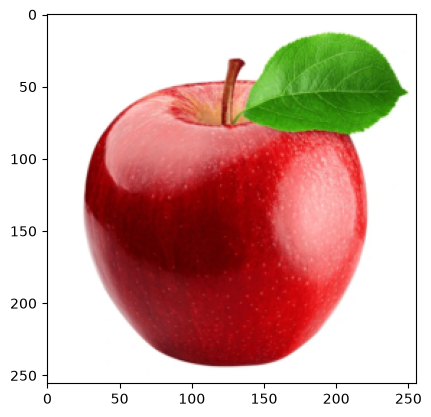

In [78]:
#  画图
plt.imshow(img_numpy)
plt.show()

In [79]:
# 4. 加入噪声，得到模型的输入
img_noise = img_tensor + torch.randn_like(img_tensor) * 0.2

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.87578285..1.8607966].


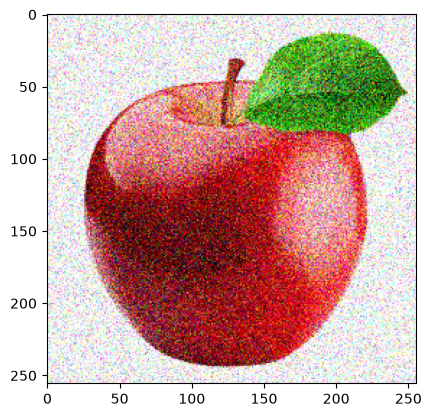

In [80]:
# 5. 将噪声图片转换为ndarray, 画图
img_noise_numpy = img_noise.permute(1, 2, 0).numpy()
plt.imshow(img_noise_numpy)
plt.show()

### 2. 定义模型

In [81]:
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        # 编码器
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1), # 输出的特征形状不变
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0), # 输出的形状为输入的一半

            nn.Conv2d(in_channels=16, out_channels=8, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, padding=0)
        )
        # 解码器
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(in_channels=8, out_channels=16, kernel_size=3, stride=2, padding=1, output_padding=1), # 输出的形状为输入的两倍
            nn.ReLU(),

            nn.ConvTranspose2d(in_channels=16, out_channels=3, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        # 编码
        features = self.encoder(x)
        print("编码输出特征形状，", features.shape)
        # 解码
        output = self.decoder(features)
        print("解码输出图像形状", output.shape)
        return output

In [82]:
model = Autoencoder()
# 测试前向传播
input = torch.randn(10, 3, 256, 256)
output = model(input)

编码输出特征形状， torch.Size([10, 8, 64, 64])
解码输出图像形状 torch.Size([10, 3, 256, 256])
